
Loading Dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Testing Images Shape  : (10000, 28, 28)

Dataset Loaded Successfully!


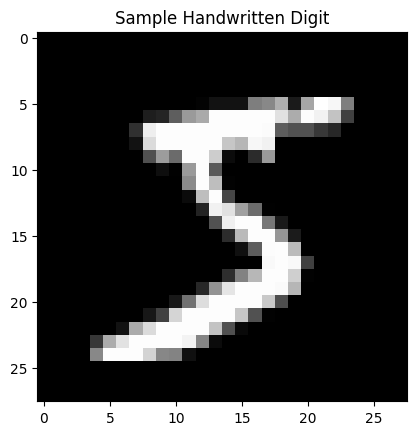


Building CNN Model...

CNN Model Created Successfully!

MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training Started...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.9283 - loss: 0.2339 - val_accuracy: 0.9822 - val_loss: 0.0531
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.9761 - loss: 0.0822 - val_accuracy: 0.9869 - val_loss: 0.0385
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9819 - loss: 0.0597 - val_accuracy: 0.9887 - val_loss: 0.0334
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9862 - loss: 0.0488 - val_accuracy: 0.9895 - val_loss: 0.0296
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.9879 - loss: 0.0408 - val_accuracy: 0.9919 - val_loss: 0.0250



Training Completed Successfully!

Model Saved Successfully!

Evaluating Model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9919 - loss: 0.0250

Test Accuracy : 99.19000267982483 %

Testing Prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

Predicted Digit : 9


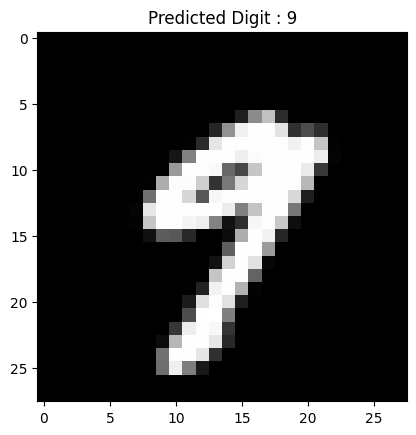


PROJECT STARTED SUCCESSFULLY

Open Browser And Visit:
http://127.0.0.1:5000
 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
# ============================================================
# PROJECT : Handwritten Character Recognition using CNN
# AUTHOR  : YOUR NAME
# TECHNOLOGY : Python + CNN + TensorFlow + Flask
# ============================================================

# =========================
# INSTALL LIBRARIES
# =========================
# Run this first in terminal or Google Colab:
#
# pip install tensorflow flask opencv-python pillow matplotlib numpy
#
# ============================================================


# =========================
# IMPORT LIBRARIES
# =========================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from flask import Flask, request, render_template_string

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical


# ============================================================
# STEP 1 : LOAD DATASET
# ============================================================

print("\n======================================")
print("Loading Dataset...")
print("======================================")

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)

# Normalize Images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Images for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels into categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("\nDataset Loaded Successfully!")


# ============================================================
# STEP 2 : DISPLAY SAMPLE IMAGE
# ============================================================

plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title("Sample Handwritten Digit")
plt.show()


# ============================================================
# STEP 3 : BUILD CNN MODEL
# ============================================================

print("\n======================================")
print("Building CNN Model...")
print("======================================")

model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN Model Created Successfully!")

print("\n======================================")
print("MODEL SUMMARY")
print("======================================")

model.summary()


# ============================================================
# STEP 4 : TRAIN MODEL
# ============================================================

print("\n======================================")
print("Training Started...")
print("======================================")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64
)

print("\nTraining Completed Successfully!")


# ============================================================
# STEP 5 : SAVE MODEL
# ============================================================

model.save("handwritten_cnn_model.h5")

print("\nModel Saved Successfully!")


# ============================================================
# STEP 6 : EVALUATE MODEL
# ============================================================

print("\n======================================")
print("Evaluating Model...")
print("======================================")

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy :", accuracy * 100, "%")


# ============================================================
# STEP 7 : SHOW PREDICTION OUTPUT
# ============================================================

print("\n======================================")
print("Testing Prediction...")
print("======================================")

sample = X_test[20]

prediction = model.predict(sample.reshape(1,28,28,1))

predicted_digit = np.argmax(prediction)

print("\nPredicted Digit :", predicted_digit)

# Display Image
plt.imshow(sample.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit : {predicted_digit}")
plt.show()


# ============================================================
# STEP 8 : FLASK WEB APPLICATION
# ============================================================

app = Flask(__name__)

# Load Saved Model
model = load_model("handwritten_cnn_model.h5")


# ============================================================
# HTML FRONTEND
# ============================================================

HTML_PAGE = '''

<!DOCTYPE html>

<html>

<head>

<title>Handwritten Character Recognition</title>

<style>

body{
    background:#0f172a;
    font-family:Arial;
    text-align:center;
    color:white;
    padding-top:40px;
}

h1{
    color:#38bdf8;
}

form{
    margin-top:30px;
}

input{
    padding:10px;
}

button{
    padding:12px 25px;
    background:#38bdf8;
    border:none;
    color:white;
    border-radius:10px;
    cursor:pointer;
    font-size:16px;
}

.result{
    margin-top:30px;
    font-size:30px;
    color:#4ade80;
}

.footer{
    margin-top:80px;
    color:gray;
}

</style>

</head>

<body>

<h1>Handwritten Digit Recognition using CNN</h1>

<h3>Deep Learning Project using TensorFlow & Flask</h3>

<form method="POST" enctype="multipart/form-data">

<input type="file" name="file">

<br><br>

<button type="submit">Predict Digit</button>

</form>

{% if prediction %}

<div class="result">

Prediction Result : {{prediction}}

</div>

{% endif %}

<div class="footer">

Designed & Developed by YOUR NAME

</div>

</body>

</html>

'''


# ============================================================
# HOME ROUTE
# ============================================================

@app.route('/', methods=['GET', 'POST'])

def home():

    prediction = None

    if request.method == 'POST':

        file = request.files['file']

        if file:

            filepath = "uploaded_image.png"

            file.save(filepath)

            # Read Image
            img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

            # Resize Image
            img = cv2.resize(img, (28,28))

            # Invert Image Colors
            img = 255 - img

            # Normalize
            img = img / 255.0

            # Reshape
            img = img.reshape(1,28,28,1)

            # Predict
            result = model.predict(img)

            prediction = np.argmax(result)

    return render_template_string(
        HTML_PAGE,
        prediction=prediction
    )


# ============================================================
# RUN APPLICATION
# ============================================================

if __name__ == "__main__":

    print("\n======================================")
    print("PROJECT STARTED SUCCESSFULLY")
    print("======================================")

    print("\nOpen Browser And Visit:")
    print("http://127.0.0.1:5000")

    app.run(debug=True)